In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pickle
from joblib import dump

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from scipy.stats import randint, uniform, loguniform

In [2]:
df = pd.read_pickle('preprocessed_data.pkl')

### Split dataset into train and test sets

In [3]:
y = df['Late_delivery_risk']
X = df.drop(columns='Late_delivery_risk')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Saving the train and test datasets as pickle for future evaluation

In [4]:
# Save training data
with open('train_data.pkl', 'wb') as f:
    pickle.dump((X_train, y_train), f)

# Save testing data
with open('test_data.pkl', 'wb') as f:
    pickle.dump((X_test, y_test), f)

In [5]:
X.drop(columns='OrderItemId', inplace=True)
X_train.drop(columns='OrderItemId', inplace=True)
X_test.drop(columns='OrderItemId', inplace=True)

Since our target variable is Binary, there are several binary‑classification models we can experiment with.

1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. XGBoost
5. Support Vector Machine (SVM with hinge loss)
6. K-Nearest Neighbors (KNN)
7. Decision Tree
8. Neural Networks (MLP)

In [6]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(early_stopping=True, random_state=42)
}

### Train, Testing and Evaluation

In [7]:
# Train, predict, and evaluate each model
for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    """
    # Use predict_proba if available to get AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC-AUC Score: {auc:.2f}")
    """

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2f}")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      0.82      0.70     16307
         1.0       0.79      0.58      0.67     19797

    accuracy                           0.69     36104
   macro avg       0.70      0.70      0.69     36104
weighted avg       0.71      0.69      0.69     36104

Confusion Matrix:
[[13305  3002]
 [ 8281 11516]]

Decision Tree
Accuracy: 0.82
Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80     16307
         1.0       0.85      0.81      0.83     19797

    accuracy                           0.82     36104
   macro avg       0.82      0.82      0.82     36104
weighted avg       0.82      0.82      0.82     36104

Confusion Matrix:
[[13452  2855]
 [ 3733 16064]]

Random Forest
Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

         0.0       0.79     

### Cross Validation (fold=5)

In [8]:
# Define CV splitter
# It ensures each fold preserves the overall class‐balance of y
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Choose the metric
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    # if the model has predict_proba and if we want AUC:
    #'roc_auc': make_scorer(roc_auc_score, needs_proba=True)
}

In [10]:
# Loop over models
for name, model in models.items():
  print(f"\n=== {name} ===")

  # cross‐validate to get metric distributions
  cv_results = cross_validate(
    model, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
  )

  #print(cv_results)

  # Print mean ± std for each metric
  for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

  # Using cross_val_predict, you get an “out‑of‑fold” prediction for every row
  # This runs an out‐of‐fold prediction on each sample
  y_pred_oof = cross_val_predict(model, X, y, cv=cv)

  print("Classification Report:")
  print(classification_report(y, y_pred_oof))

  print("Confusion Matrix:")
  print(confusion_matrix(y, y_pred_oof))


=== Logistic Regression ===
accuracy: 0.691 ± 0.002
precision: 0.796 ± 0.003
recall: 0.586 ± 0.003
f1: 0.675 ± 0.003
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      0.82      0.71     81542
         1.0       0.80      0.59      0.67     98977

    accuracy                           0.69    180519
   macro avg       0.71      0.70      0.69    180519
weighted avg       0.72      0.69      0.69    180519

Confusion Matrix:
[[66729 14813]
 [41023 57954]]

=== Decision Tree ===
accuracy: 0.816 ± 0.003
precision: 0.848 ± 0.003
recall: 0.809 ± 0.005
f1: 0.828 ± 0.003
Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80     81542
         1.0       0.85      0.81      0.83     98977

    accuracy                           0.82    180519
   macro avg       0.81      0.82      0.81    180519
weighted avg       0.82      0.82      0.82    180519

Confusion Matrix:
[[6

In [11]:
# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': loguniform(1e-4, 1e2),           # inverse regularization strength
        'penalty': ['l1', 'l2', 'elasticnet', None],
        'solver': ['saga'], # saga supports all the above
        'l1_ratio': uniform(0, 1)
    },
    'Decision Tree': {
        'max_depth': randint(1, 50),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'max_features': ['sqrt', 'log2', None]
    },
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(5, 50),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'max_features': uniform(0.3, 0.7)
    },
    'Gradient Boosting': {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 15),
        'subsample': uniform(0.5, 0.5),
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 15),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'gamma': uniform(0, 5),
        'reg_alpha': loguniform(1e-8, 1e2),
        'reg_lambda': loguniform(1e-8, 1e2)
    },
    'K-Nearest Neighbors': {
        'n_neighbors': randint(3, 30),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Neural Network': {
        'hidden_layer_sizes': [(randint.rvs(50,200),), (randint.rvs(50,200), randint.rvs(20,100))],
        'activation': ['tanh', 'relu', 'logistic'],
        'solver': ['adam', 'sgd'],
        'alpha': loguniform(1e-5, 1e-1),
        'learning_rate_init': uniform(1e-4, 1e-1)
    }
}

In [12]:
# Dictionary to store the best models after tuning
best_models = {}
entire_cv_resut = {}

# Perform hyperparameter tuning on each model with the pipeline
for name, model in models.items():
    print(f"Tuning {name}...")

    # Use either GridSearchCV or RandomizedSearchCV depending on the model
    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    n_iter=100,                  # number of different combinations to try
    scoring='f1',          # or 'accuracy', 'f1', roc_auc etc.
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42,
    error_score='raise'                    # will stop immediately on invalid params
    )

    # Fit the search to the data
    random_search.fit(X_train, y_train)
    best_models[name] = random_search.best_estimator_
    entire_cv_resut[name] = random_search

    print(f"Best parameters for {name}: {random_search.best_params_}")

Tuning Logistic Regression...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters for Logistic Regression: {'C': np.float64(0.017670169402947963), 'l1_ratio': np.float64(0.9507143064099162), 'penalty': 'elasticnet', 'solver': 'saga'}
Tuning Decision Tree...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters for Decision Tree: {'max_depth': 31, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuning Random Forest...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters for Random Forest: {'max_depth': 35, 'max_features': np.float64(0.9745339839624769), 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 355}
Tuning Gradient Boosting...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters for Gradient Boosting: {'learning_rate': np.float64(0.25223204654921877), 'max_depth': 14, 'max_features': 'sqrt', 'n_estimators': 280, 'subsample': np.float64(0.95341

### Evaluation

In [13]:
# evaluation matrix
# Evaluate each model on the test set
eval_matrix = []
for name, model in best_models.items():
  print(f"Evaluating {name}...")
  # Predict on the test set
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  print(f"Accuracy: {acc:.2f}")

  print("Classification Report:")
  print(classification_report(y_test, y_pred))

  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred))
  print()

Evaluating Logistic Regression...
Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      0.82      0.70     16307
         1.0       0.79      0.58      0.67     19797

    accuracy                           0.69     36104
   macro avg       0.70      0.70      0.69     36104
weighted avg       0.71      0.69      0.69     36104

Confusion Matrix:
[[13305  3002]
 [ 8281 11516]]

Evaluating Decision Tree...
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.83      0.80     16307
         1.0       0.85      0.79      0.82     19797

    accuracy                           0.81     36104
   macro avg       0.81      0.81      0.81     36104
weighted avg       0.81      0.81      0.81     36104

Confusion Matrix:
[[13489  2818]
 [ 4063 15734]]

Evaluating Random Forest...
Accuracy: 0.84
Classification Report:
              precision    recall  f1-scor

Save the models and also the entire optimisation object for visualisation and further evaluation

In [14]:
# Save each model
for name, model in best_models.items():
  dump(model, f'{name}_model.joblib')

# Save each model'S entire details
for name, model in entire_cv_resut.items():
  dump(model, f'{name}_model_details.joblib')

# Save each model'S entire details in .pkl file
for name, model in entire_cv_resut.items():
  with open(f'{name}_model_details.pkl', 'wb') as f:
    pickle.dump(model, f)

### Comparison of the models based on Visualisation

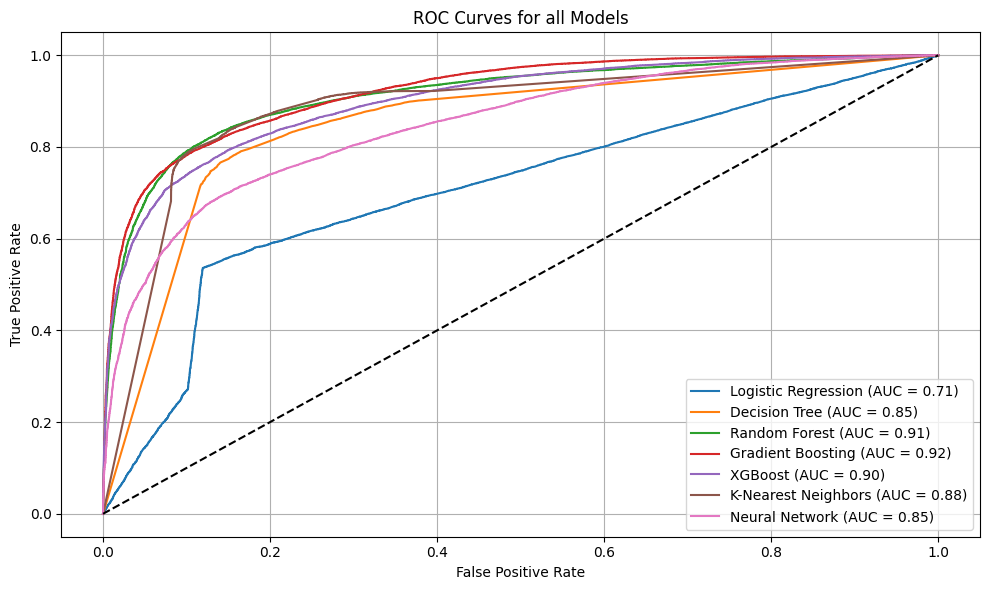

In [15]:
plt.figure(figsize=(10, 6))
for name, model in best_models.items():
  # Check if the model has predict_proba method
  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr) # roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
  else:
    print(f"Model '{name}' does not have predict_proba method and will be skipped for ROC curve plotting.")


plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for all Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()